In [22]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert
import pandas as pd
import scipy as sp
import os
plt.close('all')

In [23]:
os.chdir(r'C:\Users\sydne\git\erth370\erth370-w2026-sydpas')
print(f'Directory: {os.getcwd()}')  # shows current working directory
os.makedirs(r"figures/line01/jacobian_p6_DD", exist_ok=True)

filename = r'data\line01\og_fromtomsnotes_mytopo\project_6\Dipole-Dipole_1-2018-06-12-181644.dat'
data = ert.load(filename)
print(data)

xs = np.array([s.x() for s in data.sensors()])  # an array of all elec x-positions along line
data_min = xs.min(); data_max = xs.max()
print(data_min, data_max)

08/03/26 - 20:18:20 - pyGIMLi - INFO - could not read unified data format for ERT ... try res2dinv


Directory: C:\Users\sydne\git\erth370\erth370-w2026-sydpas
Data: Sensors: 81 data: 1469, nonzero entries: ['a', 'b', 'm', 'n', 'r', 'valid']
0.0 200.0


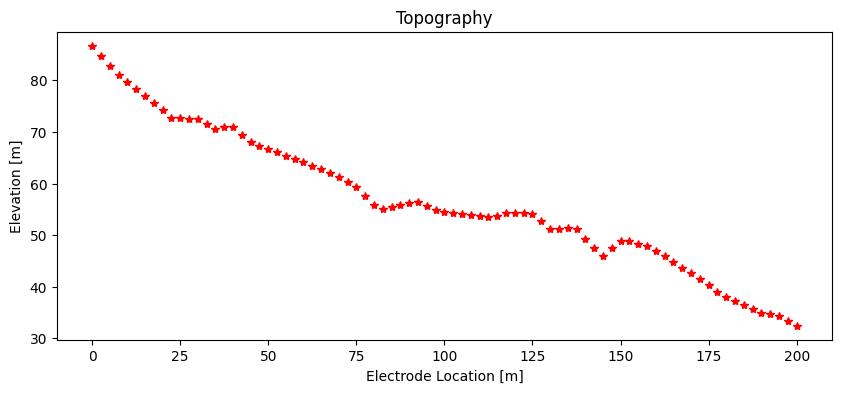

In [47]:
topo = []

topo_file = r'data\line01\og_fromtomsnotes_mytopo\line01_mytopo.txt'

with open(topo_file) as f: 
    next(f)  # skip header line
    for line in f:
        line = line.strip()
        parts = line.split()  # split using whitespace
        if len(parts) == 2:  # if data has 2 columns it is topo data so add to the list
            topo.append([float(parts[0]), float(parts[1])])

topo = np.array(topo)  # convert to numpy array

topo = topo[np.argsort(topo[:,0])]

x_elec = pg.x(data)  # get x pos of all electrodes
z_elec = np.interp(x_elec, topo[:,0], topo[:,1])  # interpolate topo at each electrode

x_elec = np.array(pg.x(data))  # convert RVector to numpy

# now we ensure topo covers all electrodes at both ends
if topo[0,0] > x_elec.min():  # if topo is to the right of (after) electrode
    topo = np.vstack(([x_elec.min(), topo[0,1]], topo))
if topo[-1,0] < x_elec.max():  # if topo is to the left of (before) electrode
    topo = np.vstack((topo, [x_elec.max(), topo[-1,1]]))

# second interp of topo at electrode positions
z_interp = np.interp(x_elec, topo[:,0], topo[:,1])

# set electrode positions in data
data.setSensorPositions(pg.PosVector(np.c_[x_elec, z_interp]))  # combine into 2D array, convert to gimli pos vector, and update elec pos in ERT dataset

# ensure arrays
x_elec = np.array(pg.x(data))
z_interp = np.array(z_interp)

plt.figure(figsize=(10,4))
plt.plot(x_elec, z_interp, 'r*')
plt.xlabel('Electrode Location [m]')
plt.ylabel('Elevation [m]')
plt.title('Topography')
plt.show()

In [48]:
def build_electrode_scheme(type,sensors_x,sensors_y):
    # build configuration (default configurations include: [‘wa’, ‘wb’, ‘pp’, ‘pd’, ‘dd’, ‘slm’, ‘hw’, ‘gr’])
    # scheme = ert.createERTData(elecs=sensors_x,schemeName=type)
    scheme = data

    # Adapt sensor positions to slope
    pos = np.array(scheme.sensors())
    for x in pos[:, 0]:
        i = np.where(pos[:, 0] == x)
        pos[i, 1] = sensors_y[i]

    scheme.setSensors(pos)

    return scheme

nelecs = 81  # from data file 
pos = np.zeros((nelecs, 2))
pos[:, 0] = np.linspace(5, 25, nelecs)
scheme = build_electrode_scheme('gr', x_elec, z_interp)

scheme["k"] = ert.createGeometricFactors(scheme)

08/03/26 - 20:22:29 - pyGIMLi - INFO - Cache c:\Users\sydne\anaconda3\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 3): C:\Users\sydne\AppData\Roaming\pygimli\Cache\13548851088150593628


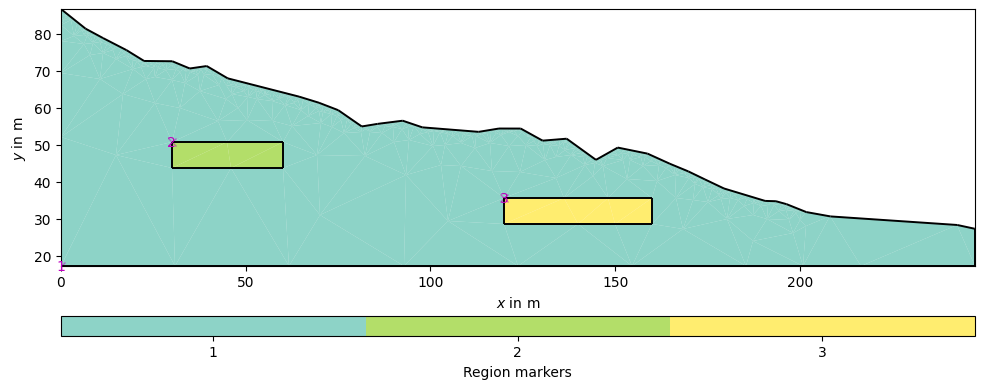

In [66]:
topo = topo[topo[:,0] <= 251]

world_bottom = topo[:,1].min() - 10

world_topo = mt.createPolygon(
    [[topo[0,0], world_bottom]] +
    topo.tolist() +
    [[topo[-1,0], world_bottom]],
    isClosed=True,
    marker=1
)

top_mean = topo[:,1].mean()

L4 = [[30, top_mean-3],
      [30, top_mean-10],
      [60, top_mean-10],
      [60, top_mean-3]]

L5 = [[120, top_mean-18],
      [120, top_mean-25],
      [160, top_mean-25],
      [160, top_mean-18]]

layer4     = mt.createPolygon(L4, isClosed=True, marker=1)
layer4_a   = mt.createPolygon(L4, isClosed=True, marker=2)
layer5     = mt.createPolygon(L5, isClosed=True, marker=1)
layer5_a   = mt.createPolygon(L5, isClosed=True, marker=3)


# merge world_topo and blocks safely
geom  = mt.mergePLC([world_topo, layer4, layer5])
geom2 = mt.mergePLC([world_topo, layer4_a, layer5_a])

# add electrodes once
for pos in scheme.sensors():
    geom.createNode([pos[0], pos[1]-0.01])
    geom2.createNode([pos[0], pos[1]-0.01])

fig, ax = plt.subplots(figsize=(16,4))
pg.show(geom2, ax=ax)

fig.savefig(r'figures/line01/jacobian_p6_DD/plot1_world', dpi=300, bbox_inches='tight')


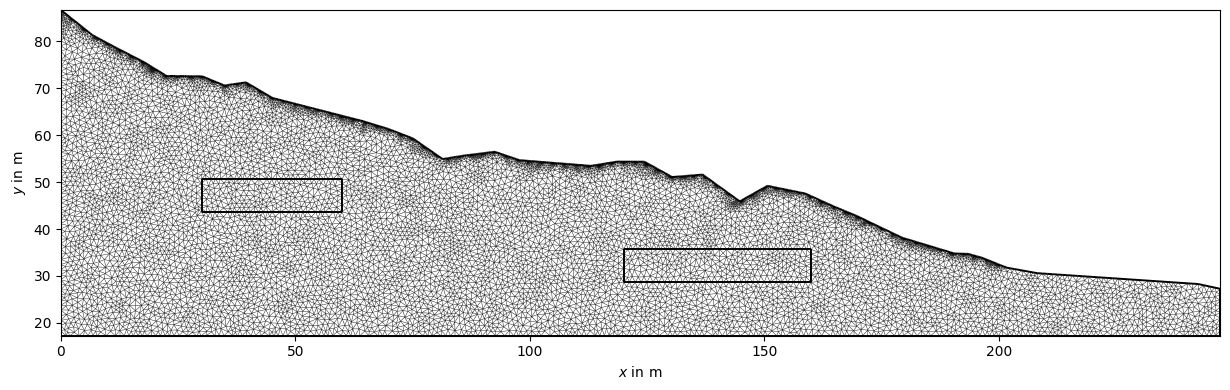

In [67]:
mesh = mt.createMesh(geom, quality=33.2, area=1)
mesh2 = mt.createMesh(geom2, quality=33.2, area=1)

mesh2.saveAscii('temp_output.txt')

fig, ax = plt.subplots(figsize=(16,4))
pg.show(mesh2, ax=ax)

fig.savefig(r'figures/line01/jacobian_p6_DD/plot2_mesh.png', dpi=300, bbox_inches='tight')


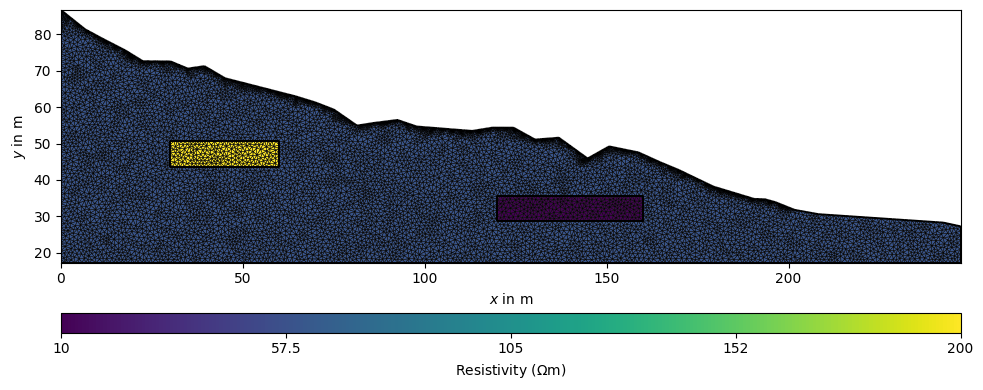

In [70]:
model_val = pd.read_csv('temp_output.txt.e',delimiter='\t',names=['one','two','three','four'])
model = np.ones(mesh.cellCount())
model[model_val.four==1] = 60
model[model_val.four==2] = 200
model[model_val.four==3] = 10


fig, ax = plt.subplots(figsize=(16,4))
pg.show(mesh, data=model, label=pg.unit('res'), showMesh=True, ax=ax)

fig.savefig(r'figures/line01/jacobian_p6_DD/plot3.png', dpi=300, bbox_inches='tight')

In [71]:
fop = ert.ERTModelling()
fop.setData(scheme)
fop.setMesh(mesh)

# fop.setRegionProperties(regionNr='*',background=False)

fop.createJacobian(model)
C = fop.constraints()

08/03/26 - 20:41:55 - pyGIMLi - INFO - Found 1 regions.
08/03/26 - 20:41:55 - pyGIMLi - INFO - Creating forward mesh from region infos.
08/03/26 - 20:41:55 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
08/03/26 - 20:41:57 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 54383 Cells: 104824 Boundaries: 80588


In [72]:
def getABMN(scheme, idx):
    """ Get coordinates of four-point cfg with id `idx` from DataContainerERT
    `scheme`."""
    coords = {}
    for elec in "abmn":
        elec_id = int(scheme(elec)[idx])
        elec_pos = scheme.sensorPosition(elec_id)
        coords[elec] = elec_pos.x(), elec_pos.y()
    return coords


def plotABMN(ax, scheme, idx):
    """ Visualize four-point configuration on given axes. """
    coords = getABMN(scheme, idx)
    for elec in coords:
        x, y = coords[elec]
        if elec in "ab":
            color = "red"
        else:
            color = "blue"
        ax.plot(x, y, marker=".", color=color, ms=10)
        ax.annotate(elec.upper(), xy=(x, y), ha="center", fontsize=10, bbox=dict(
            boxstyle="round", fc=(0.8, 0.8, 0.8), ec=color), xytext=(0, 20),
                    textcoords='offset points', arrowprops=dict(
                        arrowstyle="wedge, tail_width=.5", fc=color, ec=color,
                        patchA=None, alpha=0.75))
        ax.plot(coords["a"][0],)

def calc_res_mat(jacobian):
    temp_a = pg.utils.gmat2numpy(jacobian).transpose()
    A = np.matmul(temp_a.transpose(),temp_a)
    B = temp_a.transpose()
    resolution_matrix = sp.linalg.solve(A,B)
    return resolution_matrix

In [73]:
%matplotlib inline
resolution_matrix = calc_res_mat(fop.jacobian())

C:\Users\sydne\AppData\Local\Temp\ipykernel_25692\2806309226.py:33: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.8917466937720377e-22.
  resolution_matrix = sp.linalg.solve(A,B)


In [74]:
for i in range(0, len(fop.jacobian()), 200):
    print(f'running measurement {i}...')
    sens = fop.jacobian()[i]

    fig, ax = plt.subplots(2,1, figsize=(12,4))

    normsens = pg.utils.logDropTol(sens/mesh.cellSizes(), 8e-4)

    if i==0:
        norm_sum = np.abs(normsens)
        res_sum = resolution_matrix[i,:]
    else:
        norm_sum = norm_sum+np.abs(normsens)
        res_sum = res_sum+resolution_matrix[i,:]

    normsens = np.abs(normsens)
    normsens /= np.max(normsens)

    plotABMN(ax[0], scheme, i)
    pg.show(mesh,normsens, cMap="jet", orientation="vertical",
        label="Normalized Sensitivity", nLevs=3,ax=ax[0])
    # ax[0].set_ylim([-10,5])

    plotABMN(ax[1], scheme, i)
    pg.show(mesh,resolution_matrix[i,:]/np.max(resolution_matrix[i,:]), cMap="turbo", orientation="vertical",
        label="Normalized Resolution", nLevs=3,ax=ax[1],cMin=0,cMax=0.15)
    # ax[1].set_ylim([-10,5])

    fig.savefig(rf'figures/line01/jacobian_p6_DD/{i}_norm_sens_res.png', dpi=300, bbox_inches='tight')

    # display(fig)

plt.close('all')

running measurement 0...
running measurement 200...
running measurement 400...
running measurement 600...
running measurement 800...
running measurement 1000...
running measurement 1200...
running measurement 1400...


for **norm_sum**: areas with higher color values are the parts of the subsurface that were most sensitive across all measurements.

for **res_sum**: how well each part of the mesh is resolved over all measurements.

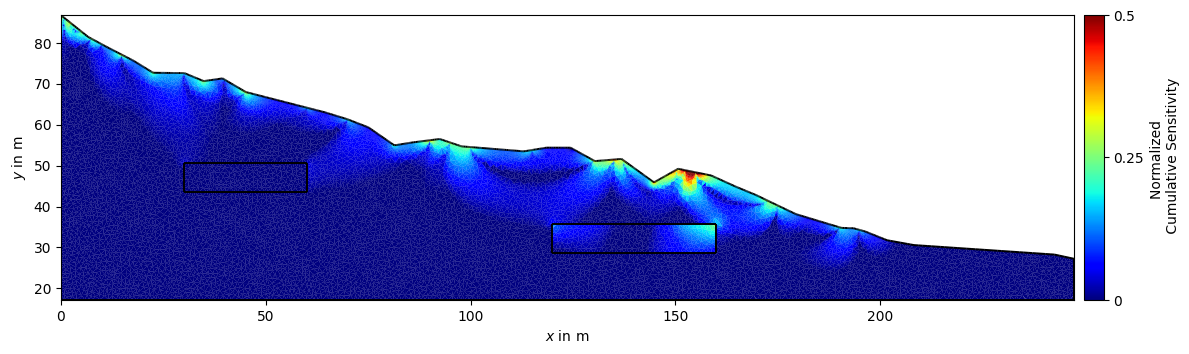

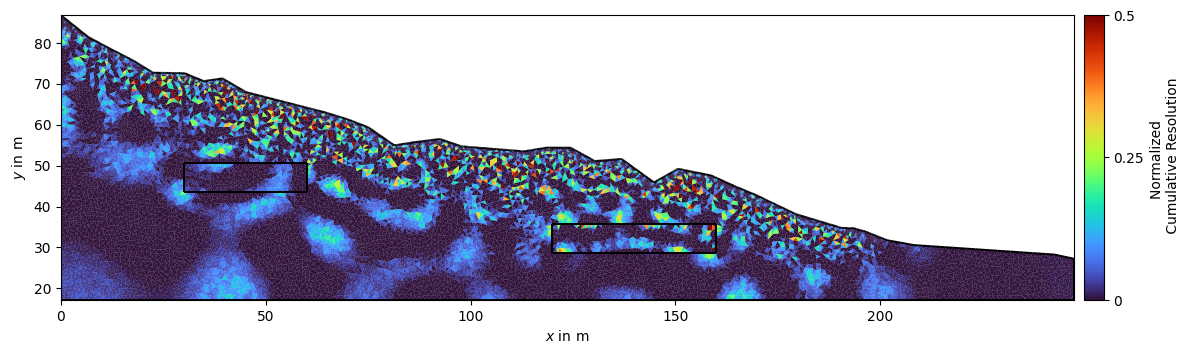

In [75]:
norm_sum /= np.max(norm_sum)

fig, ax = plt.subplots(figsize=(12, 4))

pg.show(mesh, norm_sum, cMap="jet", orientation="vertical",
        label="Normalized \n Cumulative Sensitivity", nLevs=3, cMin=0, cMax=0.5, ax=ax)

fig.savefig(r'figures/line01/jacobian_p6_DD/plot4_norm_cumu_sens.png', dpi=300, bbox_inches='tight')

#####

res_sum /= np.max(res_sum)

fig, ax = plt.subplots(figsize=(12, 4))

pg.show(mesh, res_sum, cMap="turbo", orientation="vertical",
        label="Normalized \n Cumulative Resolution", nLevs=3,cMin=0,cMax=0.5, ax=ax)

fig.savefig(r'figures/line01/jacobian_p6_DD/plot5_norm_cumu_res.png', dpi=300, bbox_inches='tight')
